# Bank Client Portfolio: EDA for Risk, Engagement & Relationship Segmentation

## Business Objective

The objective of this analysis is to explore the customer portfolio, understand the financial characteristics associated with lending risk, identify potentially higher-risk customer segments, and translate the findings into actionable insights for risk monitoring.

 **Analytical Questions**
1. What does the customer portfolio look like?
2. What are the main financial exposures?
3. How is risk distributed across customers?
4. Which customer characteristics are associated with higher risk?
5. Is risk concentrated by income, relationship type, tenure or other customer characteristics?

The analysis will move from understanding the portfolio and validating the data, to examining financial exposure and risk, identifying characteristics associated with higher risk, and finally translating those findings into business recommendations.

## 1. Setup and Data Loading

We have four related tables: the main `Clients - Banking` fact table, plus three lookup tables (`Gender`, `Banking Relationship`, `Investment Advisor`) that are joined in via ID columns (`GenderId`, `BRId`, `IAId`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
banking = pd.read_csv("Banking.csv")
gender = pd.read_csv("Gender.csv")
banking_relationship = pd.read_csv("BankingRelationship.csv")
investment_advisor = pd.read_csv("InvestmentAdvisor.csv")

In [3]:
# Merging the tables into one so we can analyze by readable labels (Gender, Banking Relationship, Investment Advisor) instead of raw IDs
banking = banking.merge(gender, on="GenderId", how="left")
banking = banking.merge(banking_relationship, on="BRId", how="left")
banking = banking.merge(investment_advisor, on="IAId", how="left")

In [4]:
banking

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId,Gender,Banking Relationship,Investment Advisor
0,IND81288,Raymond Mills,24,34324,2019-05-06 00:00:00,Anthony Torres,American,Safety Technician IV,High,Jade,...,12249.9584,1.134475e+06,1,2,1,1,1,Male,Retail,Victor Dean
1,IND65833,Julia Spencer,23,42205,2001-12-10 00:00:00,Jonathan Hawkins,African,Software Consultant,High,Jade,...,61162.3089,2.000526e+06,1,3,2,1,2,Male,Institutional,Jeremy Porter
2,IND47499,Stephen Murray,27,7314,2010-01-25 00:00:00,Anthony Berry,European,Help Desk Operator,High,Gold,...,79071.7794,5.481376e+05,1,3,3,2,3,Female,Private Bank,Ernest Knight
3,IND72498,Virginia Garza,40,34594,2019-03-28 00:00:00,Steve Diaz,American,Geologist II,Mid,Silver,...,57513.6520,1.148402e+06,0,4,4,1,4,Male,Commercial,Eric Shaw
4,IND60181,Melissa Sanders,46,41269,2012-07-20 00:00:00,Shawn Long,American,Assistant Professor,Mid,Platinum,...,30012.1360,1.674412e+06,0,3,1,2,5,Female,Retail,Kevin Kim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,2014-10-09 00:00:00,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,12947.3100,1.238860e+06,1,3,3,2,4,Female,Private Bank,Eric Shaw
2996,IND40556,Billy Williamson,44,32837,2009-02-05 00:00:00,Dennis Ruiz,European,Paralegal,Mid,Gold,...,23205.6900,2.771711e+05,1,2,3,2,5,Female,Private Bank,Kevin Kim
2997,IND72414,Victor Black,70,36088,2009-12-29 00:00:00,Joshua Ryan,American,Statistician IV,Low,Jade,...,30291.8112,5.029472e+05,2,2,3,2,6,Female,Private Bank,Victor Rogers
2998,IND46652,Andrew Ford,56,24871,2006-02-13 00:00:00,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,6413.1444,1.538369e+06,3,1,3,2,7,Female,Private Bank,Eugene Cunningham


In [5]:
banking.shape

(3000, 28)

This dataset is suitable for investigating whether customer characteristics and financial exposure are associated with the bank's existing risk weighting.

## 2. Data Cleaning and Feature Enigineering

### 2.1 Data Quality Check

In [6]:
# Find the missing values by counting the columns .isna, sum the number of missing values .sum, but only show columns where the count is greater than zero >0, and display only the columns that actually contain missing values.
print("Missing values per column:")
print(banking.isna().sum()[banking.isna().sum() > 0])
print()

#Count the duplicate Client IDs, sum them up and store that number in a variable called dup_ids.
dup_ids = banking['Client ID'].duplicated().sum()

#The f before the string means formatted string (f-string).It allows you to put a Python variable inside { }.
print(f"Duplicated Client IDs: {dup_ids}")

#If there are duplicates, show me the duplicated clients, sort them by Client ID, show only their Client ID and Name, and display the first 6.
banking[banking.duplicated('Client ID', keep=False)].sort_values('Client ID')[['Client ID','Name']].head(6)

Missing values per column:
Series([], dtype: int64)

Duplicated Client IDs: 60


,Client ID,Name
1545,IND15088,Margaret Coleman
740,IND15088,Betty Davis
378,IND15955,Susan Dunn
1081,IND15955,Victor Williams
995,IND17019,Keith Fuller
259,IND17019,Charles Richards


**Data-quality caveat:** No missing values anywhere — the dataset is complete. But `Client ID` is *not* a unique key: 60 IDs are shared by two different clients (different names, different records). This means `Client ID` can't safely be used as a join key or a "number of unique clients" count on its own. We'll keep it as-is, but we note it as a data quality caveat and rely on row-level analysis rather than ID-level joins.

### 2.2 Data Types

In [7]:
# initial profile of the dataset.
banking.dtypes

Client ID                    object
Name                         object
Age                           int64
Location ID                   int64
Joined Bank                  object
Banking Contact              object
Nationality                  object
Occupation                   object
Fee Structure                object
Loyalty Classification       object
Estimated Income            float64
Superannuation Savings      float64
Amount of Credit Cards        int64
Credit Card Balance         float64
Bank Loans                  float64
Bank Deposits               float64
Checking Accounts           float64
Saving Accounts             float64
Foreign Currency Account    float64
Business Lending            float64
Properties Owned              int64
Risk Weighting                int64
BRId                          int64
GenderId                      int64
IAId                          int64
Gender                       object
Banking Relationship         object
Investment Advisor          

### 2.3 Descriptive statistics

In [8]:
# Numerical Variables

banking.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3000.0,51.039667,19.854760,17.0000,34.000000,51.000000,6.900000e+01,8.500000e+01
Location ID,3000.0,21563.323000,12462.273017,12.0000,10803.500000,21129.500000,3.205450e+04,4.336900e+04
Estimated Income,3000.0,171305.034094,111935.808260,15919.4754,82906.594300,142313.479600,2.422903e+05,5.223303e+05
Superannuation Savings,3000.0,25531.599673,16259.950770,1482.0300,12513.775000,22357.355000,3.546474e+04,7.596390e+04
Amount of Credit Cards,3000.0,1.463667,0.676387,1.0000,1.000000,1.000000,2.000000e+00,3.000000e+00
Credit Card Balance,3000.0,3176.206780,2497.094724,1.1748,1236.633525,2560.800750,4.522633e+03,1.399199e+04
Bank Loans,3000.0,591386.155253,457557.036322,0.0000,239628.135000,479793.401700,8.258130e+05,2.667557e+06
Bank Deposits,3000.0,671560.193842,645716.856762,0.0000,204400.372299,463316.460618,9.427546e+05,3.890598e+06
Checking Accounts,3000.0,321092.949070,282079.553866,0.0000,119947.526341,242815.659293,4.348749e+05,1.969923e+06
Saving Accounts,3000.0,232908.353437,230007.777521,0.0000,74794.406243,164086.556764,3.155750e+05,1.724118e+06


In [9]:
# Categorical Variables
banking.describe(include='object').T

,count,unique,top,freq
Client ID,3000,2940,IND48103,3
Name,3000,2913,Thomas Hernandez,2
Joined Bank,3000,2579,2020-02-03 00:00:00,4
Banking Contact,3000,49,Ernest Rivera,77
Nationality,3000,5,European,1309
Occupation,3000,195,Associate Professor,28
Fee Structure,3000,3,High,1476
Loyalty Classification,3000,4,Jade,1331
Gender,3000,2,Female,1512
Banking Relationship,3000,4,Private Bank,1352


The data contains no missing values, but Client ID is not unique. I can therefore proceed with row-level analysis while treating Client ID cautiously. Next, we establish the overall customer and financial profile.

## 3. Customer Portfolio Profile

### 3.1 Tenure / Engagement features

I converted `Joined Bank` to a real date, then derived:
- **Engagement Days** — days since joining (as of the most recent join date in the dataset, used as our reference "today")
- **Engagement Years** — same, in years
- **Tenure Band** — bucketed groups so I can compare short-tenure vs long-tenure clients

In [10]:
# Take each customer's bank-joining date, calculate how long they have been with the bank, then place them into a tenure category such as < 1 year, 1-3 years, 3-5 years, etc.

### 3.1.1. Convert the Joined Bank column into a proper date format and save the result back into that column.
#### pd.to_datetime() is a pandas function that converts values into a proper date/time format. Even though they look like dates, pandas may initially treat them as ordinary text (string). pd.to_datetime() tells pandas:"These values represent dates. Treat them as dates."

banking['Joined Bank'] = pd.to_datetime(banking['Joined Bank'])

### 3.1.2. Find the most recent joining date in the dataset and store it as reference_date
### .max() finds the largest/latest value.Because this column contains dates, the largest date is the most recent date and store the date in a variable called reference_date.
### .date() extracts just the date portion, without the time.

reference_date = banking['Joined Bank'].max()
print("Reference date used for tenure calculations:", reference_date.date())

### 3.1.3. Calculate the number of days between each customer's joining date and the reference date, and save those values in Engagement Days
### the line below calculates the difference between the reference date and every customer's joining date.
### When you subtract two pandas dates, pandas gives you a time difference, called a Timedelta. The result is stored in a new column called Engagement days.

banking['Engagement Days'] = (reference_date - banking['Joined Bank']).dt.days

### Now we're converting the number of days into approximately years. We're dividing the number of days by 365.25. The .25 accounts approximately for leap years.

banking['Engagement Years'] = (banking['Engagement Days'] / 365.25).round(1)

### 3.1.4. Create a function called tenure_band

def tenure_band(years):
    if years < 1:
        return '< 1 year'
    elif years < 3:
        return '1-3 years'
    elif years < 5:
        return '3-5 years'
    elif years < 10:
        return '5-10 years'
    else:
        return '10+ years'

### 3.1.5. Apply the function to every customer
### This creates another new column ['Tenure Band'].Then selects the years column ['Engagement Years']. .apply() means: Run the tenure_band function on every value in the engagement years column and stores it in the Tenure band column.

banking['Tenure Band'] = banking['Engagement Years'].apply(tenure_band)

### Count how many customers are in each band. .value_counts() Counts how many times each category appears (This tells you: How many customers belong to each tenure category?). .sort_index() changes the ordering based on the category names.

banking['Tenure Band'].value_counts().sort_index()

Reference date used for tenure calculations: 2021-12-31


Tenure Band
1-3 years      429
10+ years     1586
3-5 years      220
5-10 years     577
< 1 year       188
Name: count, dtype: int64

The portfolio is strongly concentrated among long-tenured customers, with 52.9% having been with the bank for 10+ years.

## 4. Financial Profile

## 4.1 Income Band analysis

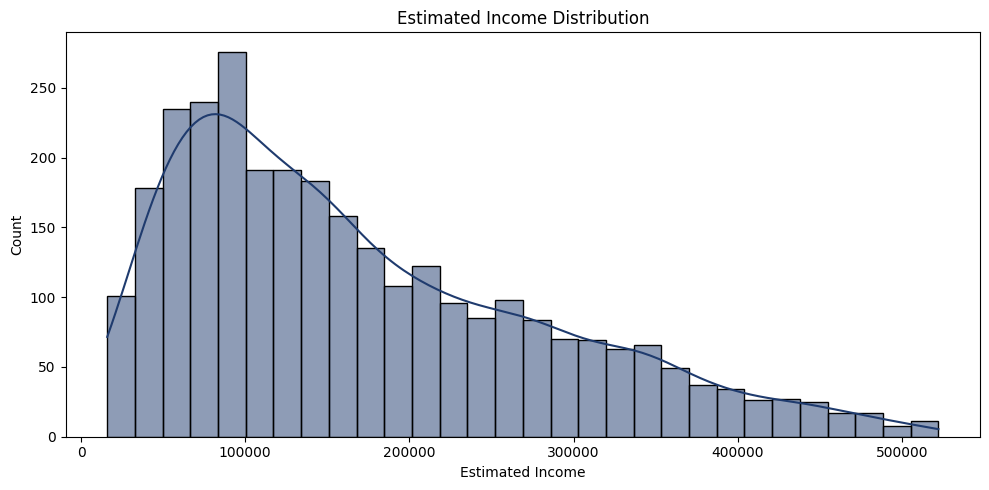

In [47]:
## 4.1.1 Estimated Income

fig, axes = plt.subplots(figsize=(10, 5))

## banking['Income'] This selects the Income column from your DataFrame. bins=30 A histogram divides the data into intervals called bins So Seaborn divides the range of ages into approximately 30 intervals (e.g.20-22,22-24,24-26). kde=True KDE means Kernel Density Estimate. It adds a smooth curve over the histogram.ax=axes[0,0] This tells Seaborn where to put the chart (e.g. top left, top middle, bottom letf).

sns.histplot(banking['Estimated Income'], bins=30, kde=True, color='#1f3b6e').set_title('Estimated Income Distribution')


## .tight_layout() This tells Matplotlib to automatically adjust the spacing between the six charts.
plt.tight_layout()
plt.show()

* A relatively smaller group of higher-income customers is pulling the average upward.
* Because income is not evenly distributed, it would be arbitrary to assume **low income = below $171K**.
* Instead, we neeed a sensible way to complete different income groups.
* Rather than fixed cutoffs, we bucket `Estimated Income` into **tertiles** (Low / Mid / High, each ~33% of clients). This is a deliberate choice: it guarantees balanced group sizes for comparison, and it's driven by the data's actual distribution rather than an arbitrary round-number cutoff.
* That leads directly to **Income Band Analysis**.


## 4.2 Income Bands

In [12]:
## 4.2.2 Income Band (tertiles):

### first line means: Take the Estimated Income values, divide customers into three equal-sized income groups, label those groups Low, Mid, and High, and store the result in a new column called Income Band.
### .qcut means quantile cut. It sorts all the customers according to income, then divide them into equal-sized groups. The income ranges won't necessarily be equal, but the number of customers in each group will be approximately equal.
### The q parameter tells qcut: "How many quantile groups should I create?" = 3 Divide the customers into 3 groups i.e. low,mid,high
### Create a new column Income Band and store the result from qcut into it. 

banking['Income Band'] = pd.qcut(banking['Estimated Income'], q=3, labels=['Low', 'Mid', 'High'])

### For each income group, what is the minimum income, maximum income, and number of customers?
### groupby() means: Separate the DataFrame into groups according to a particular column (i.e. low,mid,high). 
### observed=True tells pandas: Only show categories that actually occur in the data. With observed=True, pandas won't unnecessarily include an empty High group.
### After grouping the DataFrame by income band, you're saying: "I specifically want to analyse the Estimated Income column." So rather than performing calculations on every column, you're focusing on income.
### agg stands for aggregate. It means: Perform one or more summary calculations on each group (e.g. find the min in low, mid and high income groups)
banking.groupby('Income Band', observed=True)['Estimated Income'].agg(['min', 'max', 'count'])

,min,max,count
Income Band,,,
Low,15919.4754,98173.6000,1000
Mid,98188.9467,201867.4688,1000
High,201968.1888,522330.2592,1000


Clients were split into three equal-sized income bands of 1,000 each: Low (<~$98K), Mid (~$98K–$202K), and High (>~$202K) estimated income.

Now I have a useful analytical question:

* Does risk differ across Low-, Mid- and High-income customers?

But we're not ready to answer that yet.

**Why?**

Because I first need to understand the other side of the lending equation:

* How much are customers borrowing and how much do they hold in deposits?

So Income leads us to financial exposure.

**Why does this follow from income?**

Because income alone doesn't tell me how financially exposed a customer is.

Consider two customers:

Customer A

* Income = $300K
  
* Loans = $100K

Customer B

* Income = $300K
  
* Loans = $3M

They have the same income but very different lending exposure. So now I'm asking:

* Does the amount customers borrow relative to what they hold in deposits provide additional information about risk?

That's why I created loan-to-deposit ratio (LDR).

## 5. Lending Exposure

### 5.1 Total Loan, Total Deposit, Loan-to-Deposit Ratio:
We build `Total Loan` and `Total Deposit` from their component accounts (matching the bank's own definitions), then derive a **Loan-to-Deposit Ratio** — a standard banking risk metric: a client borrowing much more than they hold on deposit represents more repayment risk than one who is deposit-heavy.

I combined this with the bank's own `Risk Weighting` (1-5 scale) to create a simple **Risk Segment** flag.

In [13]:
### 5.1.1 Calculate and create new columns for total loan and total deposit

banking['Total Loan'] = banking['Bank Loans'] + banking['Business Lending'] + banking['Credit Card Balance']
banking['Total Deposit'] = banking['Bank Deposits'] + banking['Saving Accounts'] + banking['Checking Accounts'] + banking['Foreign Currency Account']

### 5.1.2 Calculate and create a column for the Loan-to-Deposit Ratio
### np.where means If this condition is true, use this value; otherwise, use another value.
### If the client has deposits greater than zero, calculate their Loan-to-Deposit Ratio.
### What is np.nan? NaN means: Not a Number. We cannot calculate a meaningful Loan-to-Deposit Ratio because this client has no deposits.
### For every client, calculate loans divided by deposits if they have deposits greater than zero; otherwise, record the ratio as missing (NaN).

banking['Loan to Deposit Ratio'] = np.where(
    banking['Total Deposit'] > 0,
    banking['Total Loan'] / banking['Total Deposit'],
    np.nan
)

### This line tells you: How many clients have absolutely no deposits?
print(f"Clients with zero total deposit: {(banking['Total Deposit'] == 0).sum()}")

### 5.1.3 Generate descriptive statistics 
### This is the final line. It's asking pandas to give you summary statistics for the three newly created financial measures.
### .describe() produces common descriptive statistics (e.g. count mean,std,min,25%,50%,75%, max)
banking[['Total Loan', 'Total Deposit', 'Loan to Deposit Ratio']].describe()

Clients with zero total deposit: 0


,Total Loan,Total Deposit,Loan to Deposit Ratio
count,3.000000e+03,3.000000e+03,3000.000000
mean,1.461322e+06,1.255445e+06,3.153153
std,9.312684e+05,1.077426e+06,16.627206
min,5.595171e+04,9.540370e+02,0.054245
25%,7.704137e+05,4.576335e+05,0.771047
50%,1.225764e+06,9.436776e+05,1.229505
75%,1.958647e+06,1.736667e+06,2.301958
max,6.078679e+06,6.485442e+06,544.435691


**Loan-to-Deposit Ratio —** no clients have zero total deposits, so the ratio is available for all 3,000 clients. The median LDR is 1.23, meaning the typical client has loans equal to approximately 123% of their deposits. However, the distribution is heavily right-skewed: the mean is 3.15 compared with a median of 1.23, while the maximum reaches 544.44. This indicates that a small number of clients have loans vastly larger than their deposits and pull the mean upward. The distribution should therefore be visualized before drawing conclusions from the average.

### 5.2 LDR Distribution

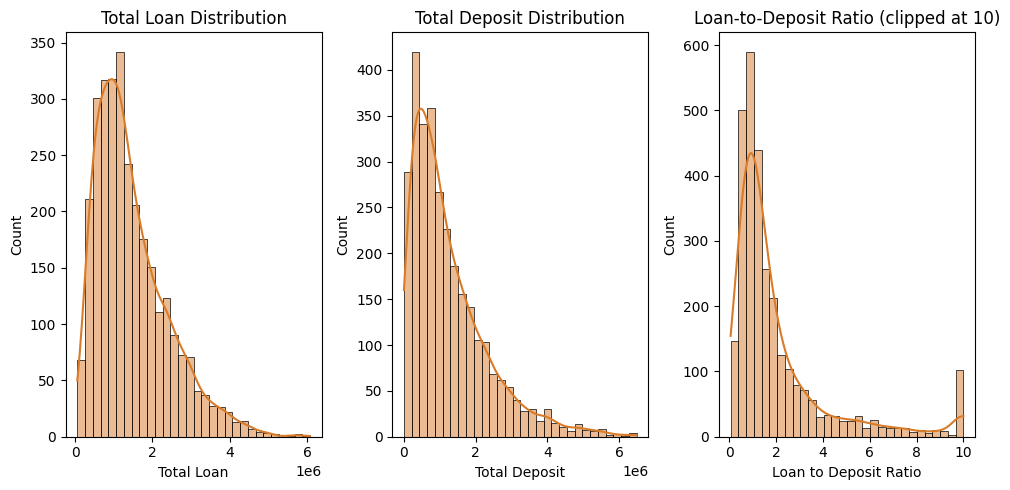

In [55]:
## line 1 is an instruction on how and where the diagrams should look and be placed. plt.subplots() creates multiple plotting areas at once (e.g. 2 rows 3 columns). Figsize= sets the width and length of all the graphs.

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

sns.histplot(banking['Total Loan'], bins=30, kde=True, ax=axes[0], color='#d97b29')
axes[0].set_title('Total Loan Distribution')

sns.histplot(banking['Total Deposit'], bins=30, kde=True, ax=axes[1], color='#d97b29')
axes[1].set_title('Total Deposit Distribution')

## .clip(upper=10) It means: Don't allow values above 10 to appear above 10 in this visualization.

sns.histplot(banking['Loan to Deposit Ratio'].clip(upper=10), bins=30, kde=True, ax=axes[2], color='#d97b29')
axes[2].set_title('Loan-to-Deposit Ratio (clipped at 10)')

## .tight_layout() This tells Matplotlib to automatically adjust the spacing between the six charts.
plt.tight_layout()
plt.show()

The Loan-to-Deposit Ratio is strongly right-skewed, with a noticeable group of extreme values. The spike at **10** represents clients with ratios above 10 that have been grouped together at the chart's upper limit. So, this isn't just a problem with the way the chart is displayed — it points to a genuine group of clients who have borrowed significantly more than they hold in deposits.

**So what do we do next?**

Now we know:

* There are potentially highly leveraged customers.

* But we don't yet know whether those customers are actually considered higher risk by the dataset.

That's the crucial transition.

**We now move to:**

Risk Weighting

## 6. Existing Risk Profile

### 6.1 Risk Weighting distribution

In [15]:
## 6.1.1
banking['Risk Weighting'].value_counts().sort_index()

Risk Weighting
1     836
2    1222
3     460
4     322
5     160
Name: count, dtype: int64

Up to this point, we have been building our understanding of the customer.

Now we introduce:

* the dataset's existing risk indicator.

That means Risk Weighting should become the anchor variable for the remainder of the EDA.

From this point onward, our question becomes:

* **"What characteristics are associated with higher Risk Weighting?"**

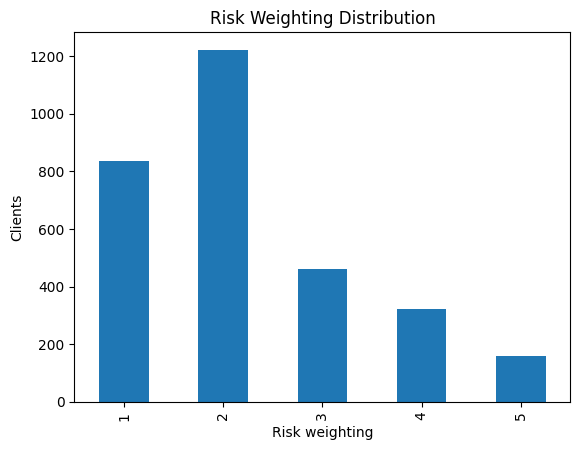

In [16]:
## 6.1.2 How is the bank's existing risk weighting distributed?

banking['Risk Weighting'].value_counts().sort_index().plot(
    kind='bar',
    xlabel = 'Risk weighting',
    ylabel = 'Clients',
    title = 'Risk Weighting Distribution'
)

plt.show()

### 6.2 Risk Weighting vs Financial Variables

**Compare Risk Weighting against the financial variables**

Ask:

What does Risk Weighting look like across income, loans, deposits and LDR?

In [17]:
## 6.2.1 Analyses on Risk Weighting against every major financial variable
## Why median? Because the financial variables are skewed.

risk_summary = banking.groupby('Risk Weighting')[
    [
        'Estimated Income',
        'Total Loan',
        'Total Deposit',
        'Loan to Deposit Ratio',
        'Age'
    ]
].median()

risk_summary

,Estimated Income,Total Loan,Total Deposit,Loan to Deposit Ratio,Age
Risk Weighting,,,,,
1,74861.8374,7.448442e+05,5.715201e+05,1.209909,51.0
2,151522.0698,1.276206e+06,9.572193e+05,1.264283,51.0
3,256053.6606,1.728687e+06,1.379392e+06,1.164928,50.0
4,289627.0962,1.953905e+06,1.609211e+06,1.219563,50.0
5,311787.7773,2.097268e+06,1.699456e+06,1.153191,49.0


**Why median?**

Because we already learned that the financial variables are skewed.

LDR is heavily skewed
        ↓
Means can be distorted
        ↓
Use medians when comparing financial profiles
        ↓
Compare medians across Risk Weighting

## 7. Identifying Risk Drivers

### 7.1 Correlation

In [98]:
## a focused correlation matrix containing only meaningful numerical risk variables
## Calculate the correlations between all the variables in risk_vars and save the result as corr
risk_vars = [
    'Age',
    'Estimated Income',
    'Bank Loans',
    'Business Lending',
    'Credit Card Balance',
    'Total Loan',
    'Total Deposit',
    'Loan to Deposit Ratio',
    'Risk Weighting'
]

pearson_corr = banking[risk_vars].corr()

pearson_corr.round(2)


,Age,Estimated Income,Bank Loans,Business Lending,Credit Card Balance,Total Loan,Total Deposit,Loan to Deposit Ratio,Risk Weighting
Age,1.00,-0.00,0.00,0.00,0.00,0.00,-0.01,0.03,-0.00
Estimated Income,-0.00,1.00,0.33,0.33,0.30,0.39,0.29,-0.00,0.66
Bank Loans,0.00,0.33,1.00,0.42,0.37,0.78,0.37,0.04,0.42
Business Lending,0.00,0.33,0.42,1.00,0.35,0.89,0.43,0.01,0.42
Credit Card Balance,0.00,0.30,0.37,0.35,1.00,0.43,0.38,-0.01,0.40
Total Loan,0.00,0.39,0.78,0.89,0.43,1.00,0.48,0.03,0.50
Total Deposit,-0.01,0.29,0.37,0.43,0.38,0.48,1.00,-0.14,0.39
Loan to Deposit Ratio,0.03,-0.00,0.04,0.01,-0.01,0.03,-0.14,1.00,-0.01
Risk Weighting,-0.00,0.66,0.42,0.42,0.40,0.50,0.39,-0.01,1.00


### 7.2 Spearman Correlation

In [100]:
## Pearson correlation measures linear association, while Spearman correlation measures monotonic association and is less sensitive to extreme values.

spearman_corr = banking[risk_vars].corr(method='spearman')

spearman_corr.round(3)

,Age,Estimated Income,Bank Loans,Business Lending,Credit Card Balance,Total Loan,Total Deposit,Loan to Deposit Ratio,Risk Weighting
Age,1.000,0.000,-0.002,-0.003,0.004,-0.003,0.001,-0.001,0.000
Estimated Income,0.000,1.000,0.304,0.328,0.269,0.401,0.298,-0.015,0.680
Bank Loans,-0.002,0.304,1.000,0.362,0.304,0.745,0.339,0.201,0.405
Business Lending,-0.003,0.328,0.362,1.000,0.296,0.872,0.402,0.240,0.422
Credit Card Balance,0.004,0.269,0.304,0.296,1.000,0.376,0.337,-0.077,0.369
Total Loan,-0.003,0.401,0.745,0.872,0.376,1.000,0.469,0.253,0.523
Total Deposit,0.001,0.298,0.339,0.402,0.337,0.469,1.000,-0.692,0.382
Loan to Deposit Ratio,-0.001,-0.015,0.201,0.240,-0.077,0.253,-0.692,1.000,-0.014
Risk Weighting,0.000,0.680,0.405,0.422,0.369,0.523,0.382,-0.014,1.000


The strongest relationship is between Risk Weighting and Estimated Income (0.680), suggesting that higher-income clients tend to have higher risk weightings. Loan to Deposit Ratio has almost no correlation with Risk Weighting (-0.014), while Total Loan is strongly related to its component lending variables, especially Business Lending (0.872) and Bank Loans (0.745).

Discovered something important:

* Income appears to have a much stronger association with the existing Risk Weighting than LDR does.

Though:

* The correlation analysis suggests that Estimated Income is more strongly associated with Risk Weighting than the Loan-to-Deposit Ratio. This does not establish causation, but it gives us a reason to investigate whether higher-income customers are disproportionately represented in the higher-risk categories.

And that leads perfectly to:

* **Risk by Income Band**

### 7.3 Income vs Risk

In [20]:
## Risk Weighting × Income Band

pd.crosstab(
    banking['Income Band'],
    banking['Risk Weighting'],
    normalize='index'
) * 100

Risk Weighting,1,2,3,4,5
Income Band,,,,,
Low,61.0,31.4,4.6,2.4,0.6
Mid,22.6,55.6,11.4,7.2,3.2
High,0.0,35.2,30.0,22.6,12.2


**Why are we doing this?**

Because correlation told us:

* Income and Risk Weighting are strongly associated.

* But correlation gives us a single number.

We now want to understand the relationship in a way a manager can easily interpret:

* What percentage of Low-, Mid- and High-income customers fall into higher-risk categories?

That's why the income-band analysis follows correlation.

## 8. Derived Risk Segmentation

### 8.1 Risk Segment Methodology

What the Risk Segment is actually doing

* isn't replacing Risk Weighting.

* It is combining two dimensions:

Dimension 1

Existing Risk Weighting

Dimension 2

Loan-to-Deposit Ratio

So:
* Risk Weighting = existing risk indicator

* LDR = financial exposure/leverage indicator

* Risk Segment = combined analytical classification

**The Risk Segment is a derived analytical classification rather than a replacement for the existing Risk Weighting. It combines the bank's existing Risk Weighting with Loan-to-Deposit Ratio to identify customers who show both elevated assigned risk and relatively high lending exposure.**

In [21]:
### 8.1.1 Defining the function risk_segment. For each row in my DataFrame, look at the information in that row and decide what risk segment it belongs to.
### line 2 This line creates a variable called: High_ratio. The purpose is to determine: Does this row have a Loan to Deposit Ratio that is greater than 1.5?
### There are actually two conditions being checked. First condition pd.notna(row['Loan to Deposit Ratio']) pd.notna() is a Pandas function that checks whether a value is not missing. Second condition row['Loan to Deposit Ratio'] > 1.5 This checks whether the Loan to Deposit Ratio is greater than 1.5. 
### line 3 another vaiable is created high_weighting It checks whether the Risk Weighting is greater than or equal to 4.

def risk_segment(row):
    high_ratio = pd.notna(row['Loan to Deposit Ratio']) and row['Loan to Deposit Ratio'] > 1.5
    high_weighting = row['Risk Weighting'] >= 4
    if high_ratio and high_weighting:
        return 'High Risk'
    elif high_ratio or high_weighting:
        return 'Elevated Risk'
    else:
        return 'Standard Risk'

### 8.1.2 Applying the function to the banking DataFrame
### apply() tells Pandas: Run a function across the DataFrame. axis=1 means: Apply the function row by row (axis=0 is column by column). Store everything in a new column risk segment.
### .value_counts() This looks at the Risk Segment column and counts how many times each category appears.
banking['Risk Segment'] = banking.apply(risk_segment, axis=1)
banking['Risk Segment'].value_counts()


Risk Segment
Standard Risk    1482
Elevated Risk    1324
High Risk         194
Name: count, dtype: int64

**Note:** This Risk Segment is an analytical classification developed for this project. The thresholds (LDR > 1.5 and Risk Weighting ≥4) are illustrative and should not be interpreted as regulatory or bank-approved credit-risk thresholds.

##### Risk Segment (combining Risk Weighting ≥4 with Loan-to-Deposit ratio >1
*  Standard Risk: 1,482 (49%)
*   Elevated Risk: 1,324 (44%)
*   High Risk: 194 (6%)

Now that we have a defined High Risk group.

The next question becomes:

* Who are these 194 customers?

### 8.2 Risk Segment Distribution

Text(0.5, 1.0, 'Clients by Risk Segment')

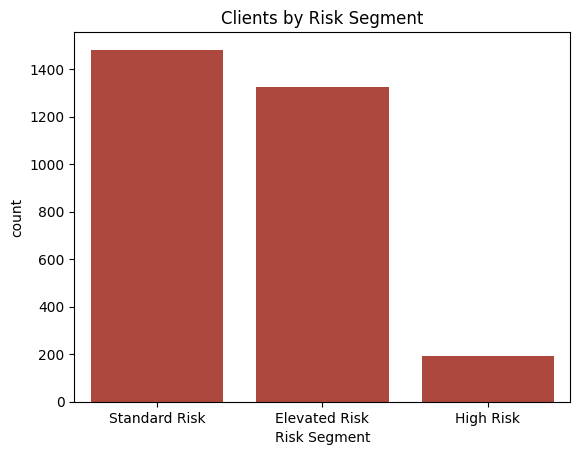

In [57]:
order_risk = ['Standard Risk', 'Elevated Risk', 'High Risk']
sns.countplot(data=banking, x='Risk Segment', order=order_risk, color='#c0392b').set_title('Clients by Risk Segment')

### 8.3 Profile of High Risk Customers

In [23]:
banking.groupby('Risk Segment')[
    ['Estimated Income',
     'Total Loan',
     'Total Deposit',
     'Loan to Deposit Ratio']
].median()

,Estimated Income,Total Loan,Total Deposit,Loan to Deposit Ratio
Risk Segment,,,,
Elevated Risk,148620.76480,1.354540e+06,5.652336e+05,2.215857
High Risk,310830.12000,2.409730e+06,7.285800e+05,2.707599
Standard Risk,126697.45355,1.052013e+06,1.297788e+06,0.852499


The typical High Risk client earns around **$310K**, compared with roughly **$127K–$149K** for clients in the other risk groups. They also have about **$2.4M in loans compared with $729K in deposits**.

This gives us a fairly clear picture of the High Risk group: they tend to be **higher-income clients who are borrowing significantly more than they hold in deposits**. Their risk appears to be linked more to their level of borrowing and income than to the type of banking relationship they have or how long they have been with the bank.

* **Looking at the distribution the High Risk group is relatively small in terms of customer count, but its customers have substantially larger financial profiles.**

* **Is this risk concentrated in a particular banking relationship?**

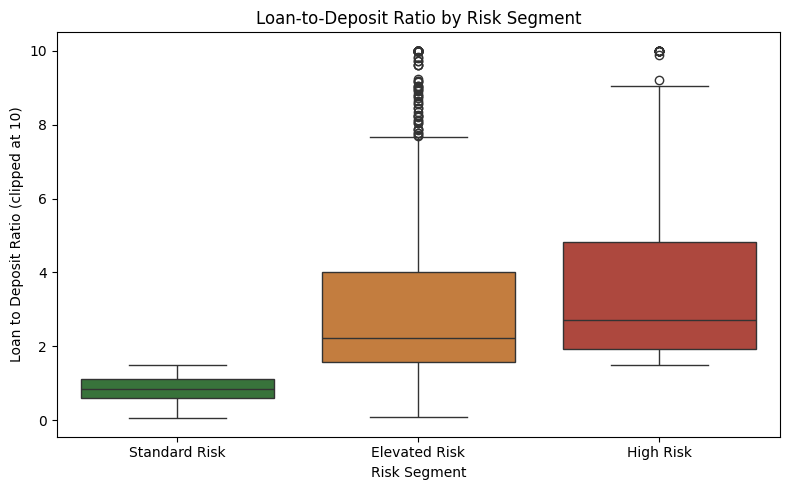

In [59]:
## 8.3.1 Loan-to-Deposit Ratio by Risk Segment

fig, ax = plt.subplots(figsize=(8,5))

order_risk = ['Standard Risk', 'Elevated Risk', 'High Risk']

sns.boxplot(
    data=banking,
    x='Risk Segment',
    y=banking['Loan to Deposit Ratio'].clip(upper=10),
    order=order_risk,
    hue='Risk Segment',
    palette=['#2e7d32', '#d97b29', '#c0392b'],
    legend=False,
    ax=ax
)

ax.set_ylabel('Loan to Deposit Ratio (clipped at 10)')
ax.set_title('Loan-to-Deposit Ratio by Risk Segment')

plt.tight_layout()
plt.show()

The boxplot shows how Loan-to-Deposit Ratio differs across the derived Risk Segments. Standard Risk customers have a median LDR of approximately 0.85, compared with 2.22 for Elevated Risk and 2.71 for High Risk. This is consistent with the segmentation methodology because LDR is one of the two inputs used to create the Risk Segment. The chart therefore helps explain the composition of each segment, rather than independently validating the risk classification.

### 8.4 Banking Relationship vs Risk

We know that:

* Private Bank is the largest group at: 1,352 / 3,000 = 45%.

Why are we analysing this?

Because management may naturally assume:

* **"Private Banking has the largest and wealthiest customers, therefore it must have the most risk."**

This analysis will test this assumption.

Risk Segment          Standard Risk  Elevated Risk  High Risk
Banking Relationship                                         
Commercial                     49.3           42.8        7.9
Institutional                  48.9           42.8        8.3
Private Bank                   50.1           44.3        5.6
Retail                         48.5           45.8        5.8


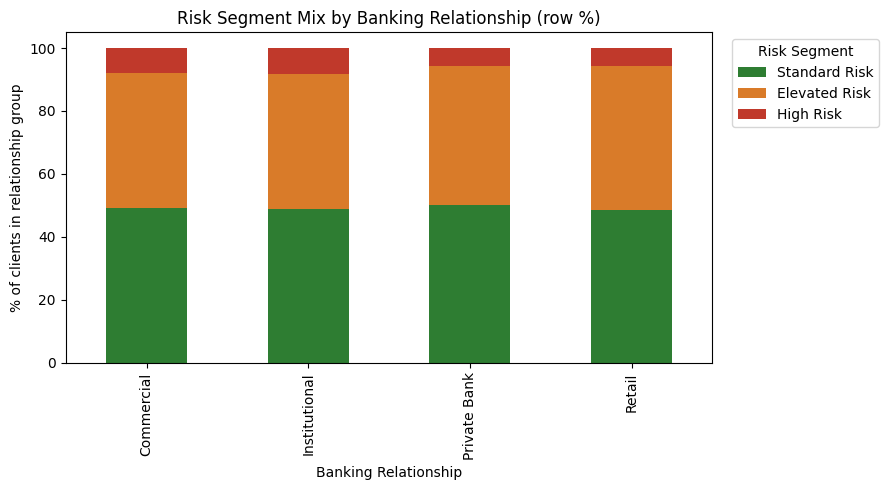

In [63]:
## pd.crosstab() creates a cross-tabulation, which is basically a frequency table showing how two categorical variables relate to each other (e.g. Banking relationship vs Risk segment).
## normalize='index' means: Calculate percentages across each row. [order_risk] from above Arrange the Risk Segment columns in this specific order.

risk_by_rel= pd.crosstab(
    banking['Banking Relationship'],
    banking['Risk Segment'],
    normalize='index',
) [order_risk] * 100
print(risk_by_rel.round(1))

## bbox_to_anchor=(1.02,1) This controls where the legend is positioned. So rather than covering part of your bars, the legend sits outside the plotting area.
## loc='upper left' This tells Matplotlib which part of the legend should be anchored to that position. Put the legend just outside the upper-right side of the chart.

fig, ax = plt.subplots(figsize=(9,5))
risk_by_rel.plot(kind='bar', stacked=True, ax=ax, color=['#2e7d32','#d97b29','#c0392b'])
ax.set_ylabel('% of clients in relationship group')
ax.set_title('Risk Segment Mix by Banking Relationship (row %)')
ax.legend(title='Risk Segment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

                      Total Loan ($M)  Total Deposit ($M)
Banking Relationship                                     
Private Bank                   1989.8              1725.7
Retail                          950.4               801.9
Commercial                      731.2               623.4
Institutional                   712.6               615.3


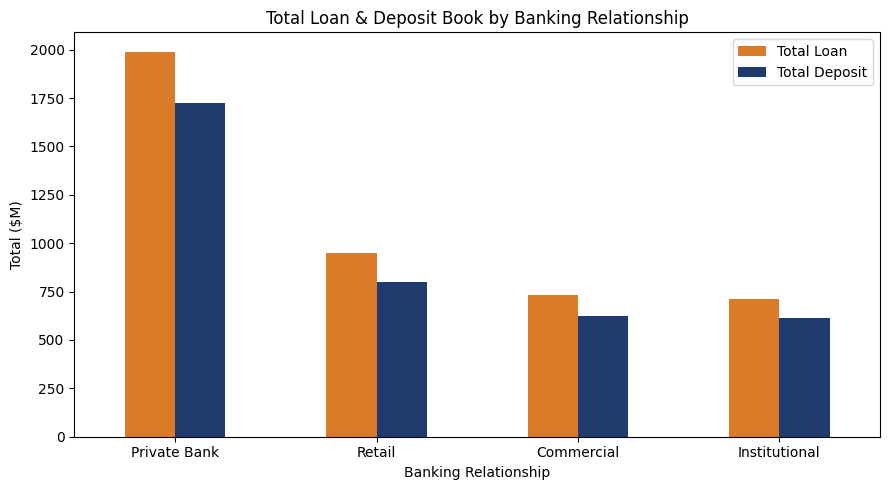

In [93]:
#Total book size by Banking Relationship:

book_by_rel = banking.groupby('Banking Relationship', observed=True)[['Total Loan','Total Deposit']].sum().sort_values('Total Loan', ascending=False)
print((book_by_rel / 1e6).round(1).rename(columns=lambda c: c + ' ($M)'))

fig, ax = plt.subplots(figsize=(9,5))
(book_by_rel/1e6).plot(kind='bar', ax=ax, color=['#d97b29','#1f3b6e'])
ax.set_ylabel('Total ($M)')
ax.set_title('Total Loan & Deposit Book by Banking Relationship')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

The 100% stacked bar chart shows the proportion of customers in each Risk Segment within each banking relationship. High Risk customers account for approximately 5.6%–8.3% of each relationship group. Although Private Bank represents 45% of the overall client base, its High Risk rate is 5.6%, which is lower than Commercial and Institutional. This suggests that banking relationship type does not materially differentiate risk in this dataset.

### 8.5 Customer Segmentation vs Risk

Why do we look at tenure?

Because we need to assume 2 important business questions:

* Could long-term customers be lower-risk because the bank has known them for longer?

Or:

* Could newer customers represent greater uncertainty?

Risk Segment  Standard Risk  Elevated Risk  High Risk
Income Band                                          
Low                    56.4           42.0        1.6
Mid                    53.2           43.4        3.4
High                   38.6           47.0       14.4


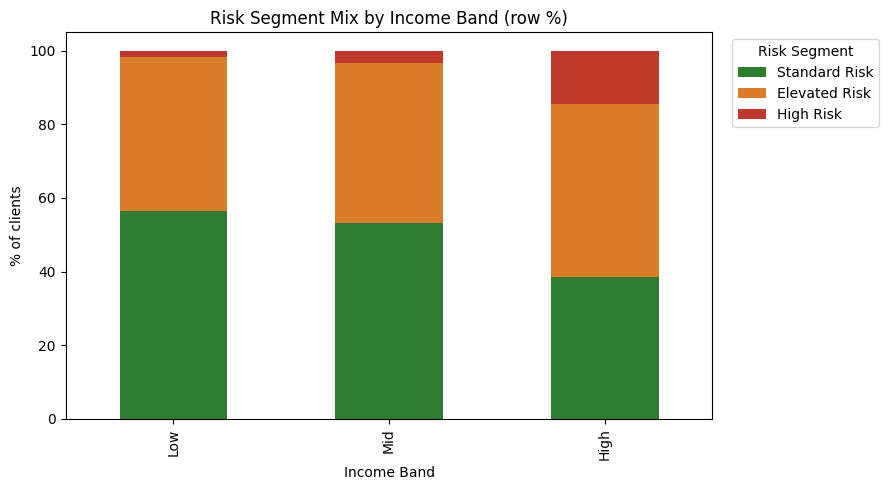

In [95]:
## 8.5.1 Income Band vs Risk

risk_by_income = pd.crosstab(banking['Income Band'], banking['Risk Segment'], normalize='index')[order_risk] * 100
print(risk_by_income.round(1))

fig, ax = plt.subplots(figsize=(9,5))
risk_by_income.plot(kind='bar', stacked=True, ax=ax, color=['#2e7d32','#d97b29','#c0392b'])
ax.set_ylabel('% of clients')
ax.set_title('Risk Segment Mix by Income Band (row %)')
ax.legend(title='Risk Segment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Income Band shows the clearest segmentation of risk in the analysis.** High Risk customers represent only around 1–2% of the Low and Mid income groups, but approximately 14% of the High income group. This supports the earlier correlation finding that Estimated Income is strongly associated with Risk Weighting. However, the result represents an association rather than evidence that high income itself causes higher risk.

In [77]:
pd.crosstab(
    banking['Tenure Band'],
    banking['Risk Segment'],
    normalize='index'
) * 100

Risk Segment,Elevated Risk,High Risk,Standard Risk
Tenure Band,,,
1-3 years,44.755245,5.827506,49.417249
10+ years,43.442623,6.872636,49.684741
3-5 years,47.272727,7.272727,45.454545
5-10 years,43.847487,5.545927,50.606586
< 1 year,45.744681,6.382979,47.872340


**Tenure does not appear to materially differentiate risk in this dataset.**

Risk Segment  Standard Risk  Elevated Risk  High Risk
Tenure Band                                          
1-3 years              49.4           44.8        5.8
10+ years              49.7           43.4        6.9
3-5 years              45.5           47.3        7.3
5-10 years             50.6           43.8        5.5
< 1 year               47.9           45.7        6.4


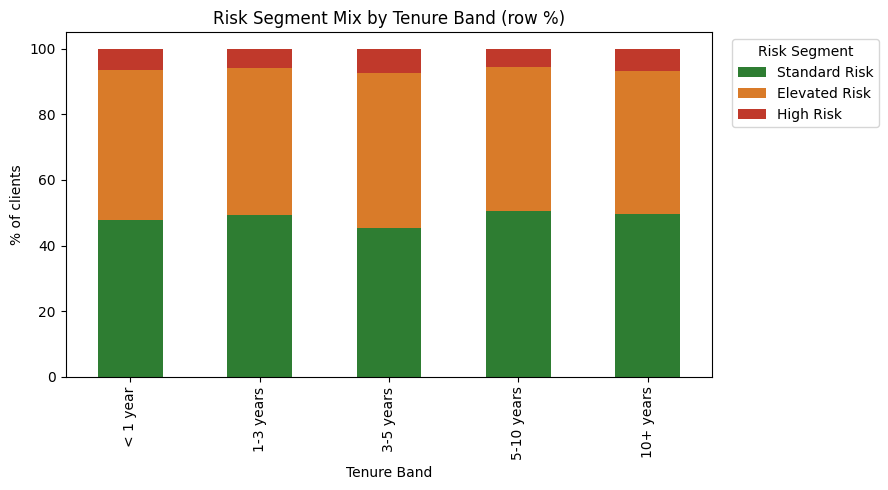

In [96]:
## 8.5.2 Risk Segment by Income Band and Tenure Band:

order_tenure = ['< 1 year', '1-3 years', '3-5 years', '5-10 years', '10+ years']

risk_by_tenure = pd.crosstab(banking['Tenure Band'], banking['Risk Segment'], normalize='index')[order_risk] * 100
print(risk_by_tenure.round(1))

fig, ax = plt.subplots(figsize=(9,5))
risk_by_tenure.loc[order_tenure].plot(kind='bar', stacked=True, ax=ax, color=['#2e7d32','#d97b29','#c0392b'])
ax.set_ylabel('% of clients')
ax.set_title('Risk Segment Mix by Tenure Band (row %)')
ax.legend(title='Risk Segment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

* **Tenure doesn't seem to make much difference to risk.** The risk breakdown is almost the same for newer clients and those who have been with the bank for 10+ years. In other words, being a long-term client doesn't automatically mean that someone is lower risk.

### 8.6 Loyalty vs Risk

* Does customer loyalty provide additional risk information?

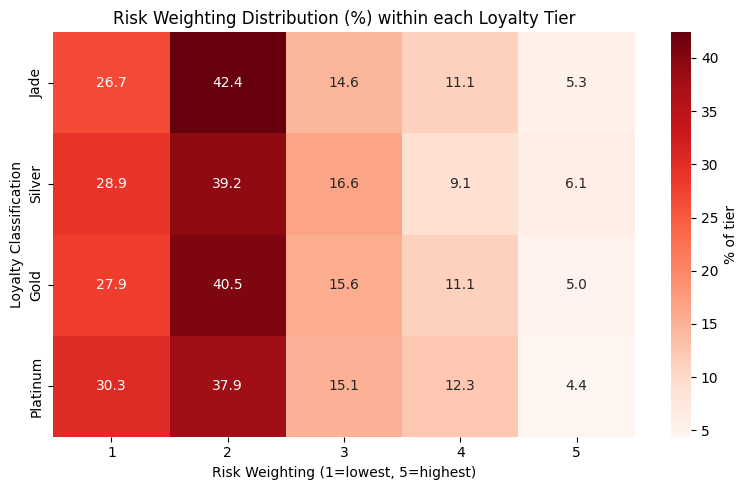

In [97]:
## 8.6.1 Loyalty tier vs Risk Weighting

loyalty_risk = pd.crosstab(banking['Loyalty Classification'], banking['Risk Weighting'], normalize='index') * 100
loyalty_order = ['Jade','Silver','Gold','Platinum']
loyalty_risk = loyalty_risk.loc[loyalty_order]

fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(loyalty_risk.round(1), annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% of tier'})
ax.set_title('Risk Weighting Distribution (%) within each Loyalty Tier')
ax.set_xlabel('Risk Weighting (1=lowest, 5=highest)')
plt.tight_layout()
plt.show()

The heatmap shows that Risk Weighting is broadly similar across the four loyalty tiers. This suggests that Loyalty Classification does not materially differentiate risk in this dataset and therefore provides limited additional value for risk segmentation.

### 8.7 Other Demographics vs Risk

* Within each demographic group, what percentage are High Risk?

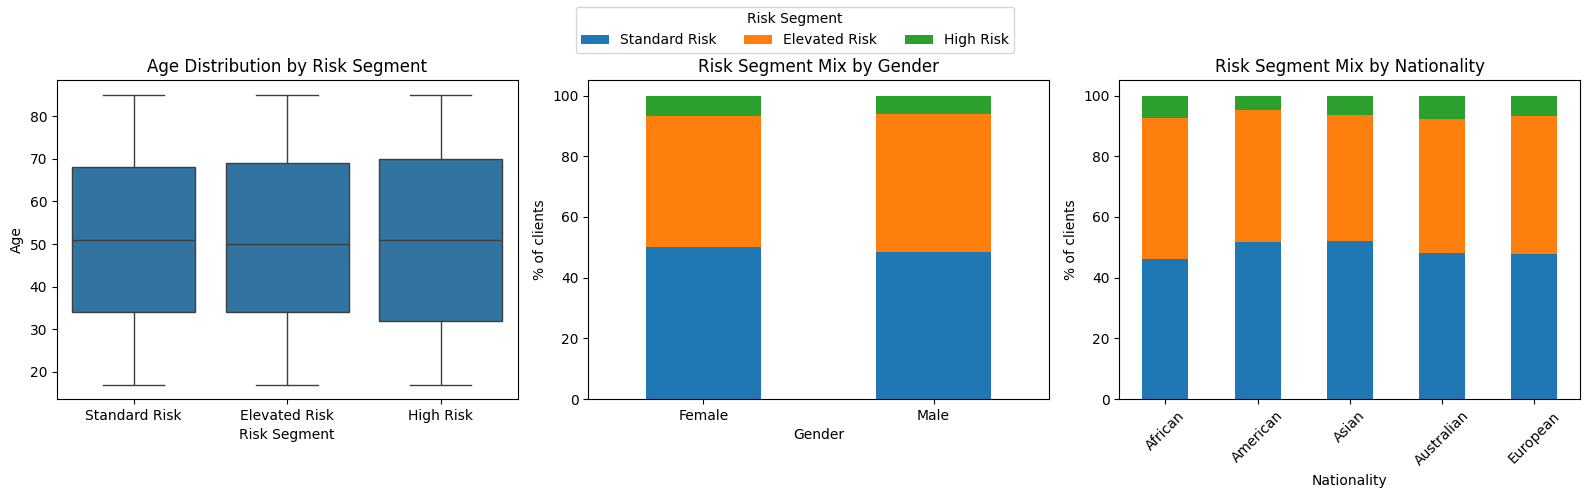

In [94]:
## 8.7.1 Are there any additional customer characteristics associated with risk?

# Create a 1x3 layout for the demographic risk analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ---------------------------------------------------------
# 1. AGE VS RISK SEGMENT
# ---------------------------------------------------------

sns.boxplot(
    data=banking,
    x='Risk Segment',
    y='Age',
    order=order_risk,
    ax=axes[0]
)

axes[0].set_title('Age Distribution by Risk Segment')
axes[0].set_xlabel('Risk Segment')
axes[0].set_ylabel('Age')


# ---------------------------------------------------------
# 2. GENDER VS RISK SEGMENT
# ---------------------------------------------------------

gender_risk = (
    pd.crosstab(
        banking['Gender'],
        banking['Risk Segment'],
        normalize='index'
    )[order_risk] * 100
)

gender_risk.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Risk Segment Mix by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('% of clients')
axes[1].tick_params(axis='x', rotation=0)
axes[1].get_legend().remove()


# ---------------------------------------------------------
# 3. NATIONALITY VS RISK SEGMENT
# ---------------------------------------------------------

nationality_risk = (
    pd.crosstab(
        banking['Nationality'],
        banking['Risk Segment'],
        normalize='index'
    )[order_risk] * 100
)

nationality_risk.plot(
    kind='bar',
    stacked=True,
    ax=axes[2]
)

axes[2].set_title('Risk Segment Mix by Nationality')
axes[2].set_xlabel('Nationality')
axes[2].set_ylabel('% of clients')
axes[2].tick_params(axis='x', rotation=45)
axes[2].get_legend().remove()


# ---------------------------------------------------------
# SHARED LEGEND
# ---------------------------------------------------------

handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Risk Segment',
    loc='upper center',
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

The demographic analysis provides limited evidence that Age, Gender or Nationality materially differentiates risk in this dataset. The Age distributions overlap substantially across Risk Segments, while the percentage-based Gender and Nationality charts allow risk rates to be compared fairly despite differences in group size. These variables therefore appear to provide less useful risk differentiation than financial characteristics such as income and lending exposure.

## 8.8 Investment Advisor analysis

* Is risk concentrated in particular advisors?

In [91]:
## Investment Advisor book sizes:

advisor_book = (
    banking.groupby('Investment Advisor', observed=True)
    .agg(
        Clients=('Client ID', 'count'),
        Total_Book_M=('Total Book', lambda x: round(x.sum() / 1e6, 1)),
        High_Risk_Clients=('Risk Segment', lambda x: (x == 'High Risk').sum()),
        High_Risk_Rate=('Risk Segment', lambda x: (x == 'High Risk').mean() * 100)
    )
    .sort_values('High_Risk_Rate', ascending=False)
)

advisor_book.round({'High_Risk_Rate': 1})

,Clients,Total_Book_M,High_Risk_Clients,High_Risk_Rate
Investment Advisor,,,,
Fred Bryant,88,244.4,9,10.2
Ryan Taylor,88,227.9,9,10.2
Peter Castillo,176,537.8,17,9.7
Nicholas Morrison,88,226.9,8,9.1
Jack Phillips,88,248.0,7,8.0
Victor Rogers,89,213.9,7,7.9
Steve Sanchez,176,432.1,13,7.4
Jeremy Porter,177,497.8,13,7.3
Carl Anderson,176,462.4,12,6.8


Advisor portfolios are almost identical in size, with approximately 176–177 clients per advisor. High Risk client counts should therefore be assessed as a percentage of each advisor's portfolio rather than by count alone. The advisor analysis is useful for monitoring portfolio allocation, but it does not provide strong evidence that advisor assignment itself is a major risk driver.

## 9. Statistical Validation

The exploratory analysis identified several apparent relationships between customer characteristics and risk. This section tests whether the main categorical relationships observed in the charts are statistically significant.

Statistical significance does not prove that one variable causes another. Instead, it helps determine whether the observed differences are unlikely to be explained by random variation in this sample.

Because the dataset contains 3,000 clients, statistical significance should be considered alongside the size and practical importance of the observed differences.

### 9.1 Income Band and Risk Segment

The Income Band analysis showed a substantial difference in the proportion of High Risk clients across income groups. A Chi-square test of independence is used to determine whether Income Band and Risk Segment are statistically associated.

In [101]:
from scipy.stats import chi2_contingency

income_risk_table = pd.crosstab(
    banking['Income Band'],
    banking['Risk Segment']
)[order_risk]

chi2, p_value, dof, expected = chi2_contingency(income_risk_table)

print("Chi-square statistic:", round(chi2, 2))
print("Degrees of freedom:", dof)
print("p-value:", p_value)

Chi-square statistic: 187.96
Degrees of freedom: 4
p-value: 1.4518035773307585e-39


In [102]:
n = income_risk_table.to_numpy().sum()
min_dimension = min(income_risk_table.shape) - 1

cramers_v = np.sqrt(
    chi2 / (n * min_dimension)
)

print("Cramér's V:", round(cramers_v, 3))

Cramér's V: 0.177


Why Cramér's V is useful

* This is important because you have 3,000 customers.
* With a large sample, even relatively small differences can become statistically significant.

### 9.2 Banking Relationship and Risk Segment

The relationship analysis showed that High Risk rates are relatively similar across Retail, Private Bank, Commercial and Institutional customers. A Chi-square test is used to determine whether Risk Segment and Banking Relationship are statistically associated.

In [103]:
relationship_risk_table = pd.crosstab(
    banking['Banking Relationship'],
    banking['Risk Segment']
)[order_risk]

chi2_rel, p_rel, dof_rel, expected_rel = chi2_contingency(
    relationship_risk_table
)

print("Chi-square statistic:", round(chi2_rel, 2))
print("Degrees of freedom:", dof_rel)
print("p-value:", p_rel)

n_rel = relationship_risk_table.to_numpy().sum()
min_dimension_rel = min(relationship_risk_table.shape) - 1

cramers_v_rel = np.sqrt(
    chi2_rel / (n_rel * min_dimension_rel)
)

print("Cramér's V:", round(cramers_v_rel, 3))

Chi-square statistic: 7.18
Degrees of freedom: 6
p-value: 0.3046153573448682
Cramér's V: 0.035


### 9.3 Tenure Band and Risk Segment

The exploratory analysis showed that the Risk Segment distribution is broadly similar across tenure bands. The Chi-square test will determine whether there is statistical evidence of an association between tenure and risk.

In [104]:
tenure_risk_table = pd.crosstab(
    banking['Tenure Band'],
    banking['Risk Segment']
)[order_risk]

chi2_tenure, p_tenure, dof_tenure, expected_tenure = chi2_contingency(
    tenure_risk_table
)

print("Chi-square statistic:", round(chi2_tenure, 2))
print("Degrees of freedom:", dof_tenure)
print("p-value:", p_tenure)

n_tenure = tenure_risk_table.to_numpy().sum()
min_dimension_tenure = min(tenure_risk_table.shape) - 1

cramers_v_tenure = np.sqrt(
    chi2_tenure / (n_tenure * min_dimension_tenure)
)

print("Cramér's V:", round(cramers_v_tenure, 3))

Chi-square statistic: 3.45
Degrees of freedom: 8
p-value: 0.9026894514377316
Cramér's V: 0.024


### 9.4 Loyalty Classification and Risk Segment

The Loyalty analysis showed that the distribution of Risk Segment appears broadly similar across the four loyalty tiers. A Chi-square test is used to determine whether Loyalty Classification and Risk Segment are statistically associated.

In [105]:
loyalty_risk_table = pd.crosstab(
    banking['Loyalty Classification'],
    banking['Risk Segment']
)[order_risk]

chi2_loyalty, p_loyalty, dof_loyalty, expected_loyalty = chi2_contingency(
    loyalty_risk_table
)

print("Chi-square statistic:", round(chi2_loyalty, 2))
print("Degrees of freedom:", dof_loyalty)
print("p-value:", p_loyalty)

n_loyalty = loyalty_risk_table.to_numpy().sum()
min_dimension_loyalty = min(loyalty_risk_table.shape) - 1

cramers_v_loyalty = np.sqrt(
    chi2_loyalty / (n_loyalty * min_dimension_loyalty)
)

print("Cramér's V:", round(cramers_v_loyalty, 3))

Chi-square statistic: 3.01
Degrees of freedom: 6
p-value: 0.8072044055272295
Cramér's V: 0.022


In [106]:
validation_summary = pd.DataFrame({
    'Relationship': [
        'Income Band vs Risk Segment',
        'Banking Relationship vs Risk Segment',
        'Tenure Band vs Risk Segment',
        'Loyalty Classification vs Risk Segment'
    ],
    'Chi-square': [
        chi2,
        chi2_rel,
        chi2_tenure,
        chi2_loyalty
    ],
    'p-value': [
        p_value,
        p_rel,
        p_tenure,
        p_loyalty
    ],
    "Cramer's V": [
        cramers_v,
        cramers_v_rel,
        cramers_v_tenure,
        cramers_v_loyalty
    ]
})

validation_summary.round({
    'Chi-square': 2,
    'p-value': 4,
    "Cramer's V": 3
})

,Relationship,Chi-square,p-value,Cramer's V
0,Income Band vs Risk Segment,187.96,0.0000,0.177
1,Banking Relationship vs Risk Segment,7.18,0.3046,0.035
2,Tenure Band vs Risk Segment,3.45,0.9027,0.024
3,Loyalty Classification vs Risk Segment,3.01,0.8072,0.022


### Interpretation

The statistical tests provide additional support for the exploratory findings. The strongest practical association should be identified using Cramér's V rather than relying on statistical significance alone.

The results should be interpreted alongside the earlier visual analysis:

- Income Band shows the clearest differentiation in risk.
- Banking Relationship shows relatively similar risk rates across groups.
- Tenure shows limited differentiation in risk.
- Loyalty shows broadly similar risk distributions across tiers.

These tests strengthen the descriptive findings but do not establish causation or prove that the derived Risk Segment predicts actual loan default.

## 10. FINAL KEY FINDINGS
**1. Data quality is generally strong, with one important identifier issue**

* The dataset contains 3,000 client records and no missing values. However, 60 Client IDs are duplicated across different client records, meaning Client ID should not be treated as a guaranteed unique customer identifier. The analysis therefore focuses on row-level records rather than assuming the ID uniquely represents one customer.

**2. The portfolio contains substantial lending exposure**

* The typical customer has approximately $1.23M in total loans and $943K in total deposits. The median Loan-to-Deposit Ratio is 1.23, meaning the typical customer's loan exposure is greater than their deposits. However, LDR is highly right-skewed, with a small number of customers showing exceptionally high ratios.

**3. Income is the strongest observed numerical correlate of Risk Weighting**

* Estimated Income has the strongest observed relationship with the bank's existing Risk Weighting, with a Pearson correlation of approximately 0.68. This indicates a strong association between higher income and higher assigned risk weighting in this dataset. This should be interpreted as an association rather than a causal relationship.

**4. High-income customers are disproportionately represented in the High Risk segment**

* High Risk customers represent approximately 6.5% of the portfolio overall. However, the High Risk rate increases from roughly 1–2% among Low and Mid income customers to approximately 14% among High income customers. This makes Income Band one of the most useful variables for distinguishing risk in the analysis.

**5. High Risk customers have substantially larger financial exposure**

* The median High Risk customer has estimated income of approximately $311K, total loans of approximately $2.41M and total deposits of approximately $729K. Their median LDR is approximately 2.71, compared with 0.85 for Standard Risk customers. This suggests that the High Risk segment is characterised by larger financial exposure as well as higher income.

**6. Banking Relationship does not materially differentiate risk**

* High Risk rates range from approximately 5.6% to 8.3% across Private Bank, Retail, Commercial and Institutional customers. Although Private Bank represents 45% of the customer base and has the largest absolute loan book, its risk rate is not materially higher than the other relationship types.

**7. Tenure and Loyalty provide limited additional risk differentiation**

* Risk distributions are broadly similar across tenure bands and loyalty tiers. Tenure therefore does not appear to materially differentiate risk in this dataset, while Loyalty Classification provides limited additional information beyond the existing risk measures.

**8. Demographic variables appear less informative than financial characteristics**

* Age, Gender and Nationality do not show a clear risk pattern comparable with Income Band and financial exposure. These variables are therefore more appropriate as secondary descriptive filters rather than primary risk-monitoring indicators.

**9. Investment Advisor portfolios are broadly similar in size**

* Advisors manage approximately 176–177 clients each, suggesting relatively even portfolio sizes. Advisor-level risk should nevertheless be monitored using High Risk rates rather than High Risk counts alone, because portfolio sizes may differ slightly.

## 11. Business Recommendations

**1. Prioritise monitoring of high-income customers with elevated financial exposure**

* The analysis indicates that High Risk customers are disproportionately concentrated within the High income group and carry substantially larger loan exposure. The bank should therefore prioritise monitoring customers who combine high income, elevated Risk Weighting and high Loan-to-Deposit Ratios.

Importantly, this does not mean high-income customers should automatically be treated as risky. The recommendation is to focus on the combination of indicators.

**2. Use Loan-to-Deposit Ratio as an exposure-monitoring KPI**

* LDR provides a useful way of identifying customers whose lending exposure is high relative to their deposits. Customers with unusually high LDR values should be available for further review, particularly where they also have elevated Risk Weighting.

**3. Use Income Band as a primary risk-analysis dimension**

* Income Band provides considerably more differentiation in risk than Tenure or Banking Relationship in this dataset. It should therefore be given greater prominence in management reporting and Power BI filtering.

**4. Do not assume Private Banking automatically means higher risk**

* Private Bank contains the largest customer base and the largest absolute loan book, but its High Risk rate is not materially higher than the other relationship types. Management should therefore distinguish between portfolio size and risk concentration rather than using absolute exposure alone.

**5. Treat Tenure and Loyalty as secondary customer-management dimensions**

* Since tenure and loyalty provide limited additional risk differentiation, they should not be treated as primary risk indicators in the dashboard. They can remain available for customer segmentation and relationship analysis but should receive less emphasis than income and financial exposure.

**6. Improve data governance before production use**

* The duplicate Client ID issue should be investigated before the analysis is used in a production environment. A reliable unique customer identifier would be important for customer-level monitoring, aggregation and future risk modelling.

## 12.Limitations

**1. Synthetic dataset**

* The dataset is synthetic, so the relationships identified in this analysis may not represent patterns that would occur in a real banking portfolio. The findings should therefore be interpreted as insights specific to this dataset rather than evidence of real-world banking behaviour.

**2. No observed default or repayment outcome**

* The dataset does not contain a clear observed loan-default, delinquency or repayment outcome. Therefore, this analysis identifies characteristics associated with the available risk measures rather than predicting actual probability of default or loan loss.

**3. Risk Segment thresholds are illustrative**

* The Risk Segment was created specifically for this analysis using LDR > 1.5 and Risk Weighting ≥4. These thresholds are illustrative and should not be interpreted as regulatory, industry-standard or bank-approved risk thresholds.

**4. Association does not imply causation**

* Relationships identified through correlation and statistical tests indicate association rather than causation. For example, the strong relationship between income and Risk Weighting does not demonstrate that higher income causes higher risk.

**5. Client ID is not a reliable unique identifier**

* Sixty Client IDs are duplicated across different client records. This limits the reliability of customer-level aggregation and should be investigated before the dataset is used for production reporting or customer-level risk monitoring.

**6. Extreme LDR values**

* The LDR distribution contains substantial outliers, including a maximum value of approximately 544. This means averages can be heavily influenced by a small number of observations. Median values and clipped visualisations are therefore used when interpreting LDR.